# Scatterplot, Plotting

In [1]:
import sys
sys.path.insert(0, '../../src/')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from utils import saver, loader


#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-11-03 11:32:15.456153: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-03 11:32:15.456373: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 11:32:15.490475: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 11:32:16.496290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Load Data

In [2]:
data = np.loadtxt("../integrable_transition/bookkeeping/figure3/scatterplot_mean.txt")
r_mean, a_mean = data[:,0], data[:,1]

data = np.loadtxt("../integrable_transition/bookkeeping/figure3/scatterplot_std.txt")
r_std, a_std = data[:,0], data[:,1]

r_baseline, a_baseline = loader("data/integrable_scatter_baseline.pkl")
r_intermediate, a_intermediate = loader("data/integrable_scatter_intermediate.pkl")


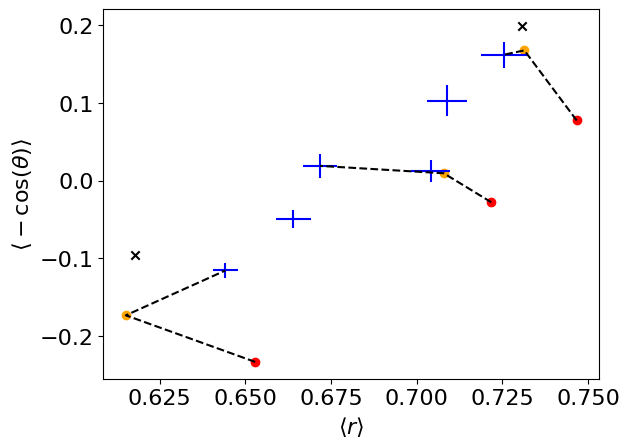

In [4]:
L_list = [5, 10, 20, 30, 40, 50]
color_list = ['red', 'orange', 'purple', 'black', 'pink', 'cyan']
AI_theory, FF_theory = np.loadtxt("../integrable_transition/bookkeeping/figure3/scatterplot_theory.txt")

plt.errorbar(r_mean[0], a_mean[0], xerr=r_std[0], yerr=a_std[0], fmt='-', label='T=5', color="b")
plt.errorbar(r_mean[1], a_mean[1], xerr=r_std[1], yerr=a_std[1], fmt='-', label='T=10', color="b")
plt.errorbar(r_mean[2], a_mean[2], xerr=r_std[2], yerr=a_std[2], fmt='-', label='T=20', color="b")
plt.errorbar(r_mean[3], a_mean[3], xerr=r_std[3], yerr=a_std[3], fmt='-', label='T=30', color="b")
plt.errorbar(r_mean[4], a_mean[4], xerr=r_std[4], yerr=a_std[4], fmt='-', label='T=40', color="b")
plt.errorbar(r_mean[5], a_mean[5], xerr=r_std[5], yerr=a_std[5], fmt='-', label='T=50', color="b")

#font size
plt.rc('font', size=16)          # controls default text sizes
#plt.plot(r_poisson, a_poisson, 'x', color='black', label='Poisson')
plt.scatter(AI_theory[0], AI_theory[1], marker='x', label='$AI_{4,1}$', color='black')
plt.scatter(FF_theory[0], FF_theory[1], marker='x', label='$FF_{4,1}$', color='black')
plt.scatter(r_baseline, a_baseline, marker='o', label='Baseline Model', color='red')
plt.scatter(r_intermediate, a_intermediate, marker='o', label='Intermediate Model', color='orange')
#plt.errorbar(r_baseline[2], a_baseline[2], xerr=0.011590525181647614, yerr=0.03820421023015067, fmt='-', label='T=50', color="red")

plt.plot([r_baseline[0], r_intermediate[0], r_mean[0]], [a_baseline[0], a_intermediate[0], a_mean[0]], '--', color='black')
plt.plot([r_baseline[1], r_intermediate[1], r_mean[2]], [a_baseline[1], a_intermediate[1], a_mean[2]], '--', color='black')
plt.plot([r_baseline[2], r_intermediate[2], r_mean[5]], [a_baseline[2], a_intermediate[2], a_mean[5]], '--', color='black')

plt.xlabel(r'$\langle r \rangle$')
plt.ylabel(r'$\langle -\cos(\theta) \rangle$')
#plt.legend()
#plt.grid()
#plt.savefig('figures/integrable_scatter.svg', bbox_inches='tight')
plt.show()
